In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
digits = load_digits( as_frame=False)

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

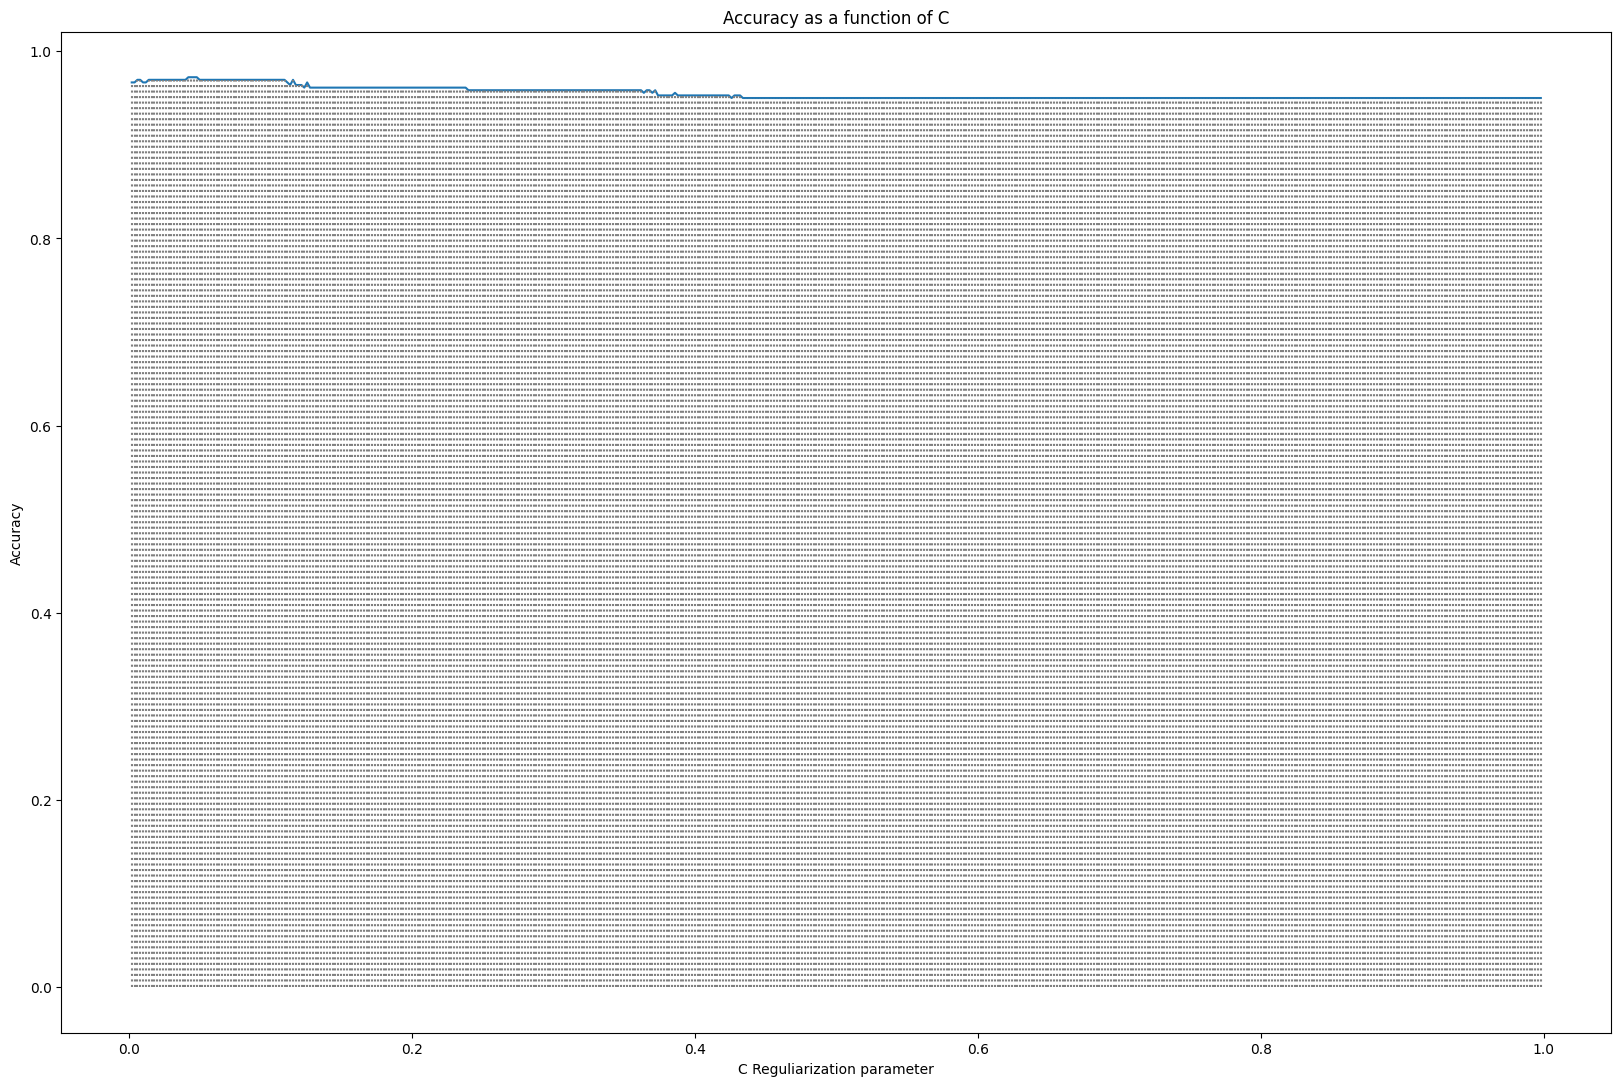

0.9722222222222222 0.042


In [7]:
Cs=np.arange(0.002,1,0.002)
accuracies=[]
optimal_c=0
optimal_accuracy=0
for C in Cs:
    lin_svc = svm . LinearSVC(C = C)
    lin_svc . fit(X_train, y_train)
    y_pred=lin_svc.predict(X_test)
    accuracy=accuracy_score(y_pred,y_test)
    accuracies.append(accuracy)
    if accuracy>optimal_accuracy:
        optimal_accuracy=accuracy
        optimal_c=C

    
plt.figure(figsize =(20,13))
plt.plot(Cs, accuracies)

plt.vlines(Cs,0, accuracies, linestyle="dotted", color="gray")
plt.xlabel("C Reguliarization parameter")
plt.ylabel("Accuracy")
plt.title("Accuracy as a function of C")
plt.show()

print(optimal_accuracy, optimal_c)


the best C is .042 and it gives an accuracy of 97%

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
  {'C': np.arange(0.2,2,0.2), 'gamma': np.arange(0.0001,0.005,0.0001), 'kernel': ['rbf']}
]

svc = svm.SVC()
# Initialize GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1,)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best cross-validation score
print(f"Best score (accuracy): {grid_search.best_score_}")

# Get the best estimator (the optimized SVM model)
best_svm_model = grid_search.best_estimator_


Best parameters: {'C': 1.4000000000000001, 'gamma': 0.0009000000000000001, 'kernel': 'rbf'}
Best score (accuracy): 0.9902608401084011


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
  {'C': np.arange(0.0002,0.002,0.00002), 'kernel': ['linear']}
]

svc = svm.SVC()
# Initialize GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1,)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best cross-validation score
print(f"Best score (accuracy): {grid_search.best_score_}")

# Get the best estimator (the optimized SVM model)
best_svm_model = grid_search.best_estimator_


Best parameters: {'C': 0.00166, 'kernel': 'linear'}
Best score (accuracy): 0.9791206929926443


Exception ignored in: <function ResourceTracker.__del__ at 0x7f2cf55de3e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fcb671de3e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fcf299b23e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multip

The default gamma parameter value is 'scale' (latest update as of currently) which uses the formula 1 / (n_features * X.var()),the other setting 'auto' uses the formula 1 / (n_features).
'scale' takes the variance into consideration ,it often leads to smaller gamma values than auto on unscaled data. 
A lower gamma means a single data point's influence reaches farther, creating a smoother, more generalized boundary. A higher gamma (common with auto on typical datasets) limits influence to very close points, potentially leading to overfitting.

In [ ]:
X.shape

(1797, 64)

The previous Grid Search parts provide accuracies for both linear and gaussian SVM, the results show that gaussian svm is better with a near perfect accuracy (it could be overfitting but unlikely since GridSearch splits the data for tuning), the difference isn't much (only 2%). But in general gaussian SVM is better for data that isn't linearly seperable (such as pixels in this case), linear svm is faster however, so it is more suited to very large datasets, the digits dataset would be considered large (70k) but in this example we only used the reduced version of 1800 so the speed difference isn't significant compared to the gain in accuracy.